In [4]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [5]:
OUTPUT_DIR = Path("../outputs/qmsum_bart_baseline")

BEST_MODEL_DIR = OUTPUT_DIR / "best_model"
CHECKPOINT_1 = OUTPUT_DIR / "checkpoint-2514"
CHECKPOINT_2 = OUTPUT_DIR / "checkpoint-3771"
SAMPLE_PREDS_FILE = OUTPUT_DIR / "sample_predictions.jsonl"

print("Best model exists:", BEST_MODEL_DIR.exists())
print("Checkpoint 2514 exists:", CHECKPOINT_1.exists())
print("Checkpoint 3771 exists:", CHECKPOINT_2.exists())
print("Sample predictions file exists:", SAMPLE_PREDS_FILE.exists())

Best model exists: True
Checkpoint 2514 exists: True
Checkpoint 3771 exists: True
Sample predictions file exists: True


In [7]:
TRAINER_STATE_FILE = CHECKPOINT_2 / "trainer_state.json"

with open(TRAINER_STATE_FILE, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

trainer_state.keys()

dict_keys(['best_global_step', 'best_metric', 'best_model_checkpoint', 'epoch', 'eval_steps', 'global_step', 'is_hyper_param_search', 'is_local_process_zero', 'is_world_process_zero', 'log_history', 'logging_steps', 'max_steps', 'num_input_tokens_seen', 'num_train_epochs', 'save_steps', 'stateful_callbacks', 'total_flos', 'train_batch_size', 'trial_name', 'trial_params'])

## Training Summary

In [8]:
print("Best model checkpoint:", trainer_state.get("best_model_checkpoint"))
print("Best metric:", trainer_state.get("best_metric"))
print("Global step:", trainer_state.get("global_step"))
print("Final epoch:", trainer_state.get("epoch"))
print("Number of log records:", len(trainer_state.get("log_history", [])))

Best model checkpoint: outputs/qmsum_bart_baseline/checkpoint-2514
Best metric: 0.2224
Global step: 3771
Final epoch: 3.0
Number of log records: 380


## Log history

In [9]:
log_history = trainer_state["log_history"]
log_df = pd.DataFrame(log_history)

display(Markdown("## Raw Log History"))
display(log_df.head(10))

## Raw Log History

,epoch,grad_norm,learning_rate,loss,step,eval_gen_len,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.007955,22.160994,0.000020,4.414310,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.015911,22.891577,0.000020,4.256769,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.023866,20.108912,0.000020,3.744703,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.031822,19.107479,0.000020,3.963139,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.039777,15.338860,0.000020,4.064204,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.047733,19.274296,0.000020,4.093596,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.055688,27.445383,0.000020,3.635284,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.063644,17.366676,0.000020,4.098128,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.071599,15.882144,0.000020,4.145433,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.079554,17.583563,0.000019,4.034874,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
train_logs = log_df[log_df["loss"].notna()] if "loss" in log_df.columns else pd.DataFrame()
eval_logs = log_df[log_df["eval_loss"].notna()] if "eval_loss" in log_df.columns else pd.DataFrame()

display(Markdown("## Training Logs"))
display(train_logs.tail(10))

display(Markdown("## Evaluation Logs"))
display(eval_logs)

## Training Logs

,epoch,grad_norm,learning_rate,loss,step,eval_gen_len,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,eval_runtime,eval_samples_per_second,eval_steps_per_second
369,2.927605,21.242414,4.879342e-07,2.242332,3680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
370,2.935561,21.055140,4.348979e-07,2.489830,3690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
371,2.943516,21.988354,3.818616e-07,2.524980,3700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
372,2.951472,24.750292,3.288252e-07,2.600724,3710,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
373,2.959427,27.059107,2.757889e-07,2.608497,3720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
374,2.967383,20.965458,2.227526e-07,2.365089,3730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
375,2.975338,26.058346,1.697163e-07,2.581764,3740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
376,2.983294,21.377760,1.166799e-07,2.461795,3750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
377,2.991249,26.577368,6.364360e-08,2.439928,3760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
378,2.999204,40.123333,1.060727e-08,2.670579,3770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Evaluation Logs

,epoch,grad_norm,learning_rate,loss,step,eval_gen_len,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,eval_runtime,eval_samples_per_second,eval_steps_per_second
125,1.0,NaN,NaN,NaN,1257,65.4154,3.382565,0.3217,0.0905,0.2218,0.2216,481.9797,0.564,0.564
252,2.0,NaN,NaN,NaN,2514,66.2059,3.378520,0.3325,0.0932,0.2224,0.2221,515.4566,0.528,0.528
379,3.0,NaN,NaN,NaN,3771,65.0147,3.555228,0.3279,0.0900,0.2199,0.2196,1693.1401,0.161,0.161


In [11]:
display(Markdown("# Validation Performance"))

eval_cols = [c for c in [
    "epoch", "step", "eval_loss", "eval_rouge1", "eval_rouge2", "eval_rougeL", "eval_gen_len"
] if c in eval_logs.columns]

eval_table = eval_logs[eval_cols].copy()
display(eval_table)

# Validation Performance

,epoch,step,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_gen_len
125,1.0,1257,3.382565,0.3217,0.0905,0.2218,65.4154
252,2.0,2514,3.378520,0.3325,0.0932,0.2224,66.2059
379,3.0,3771,3.555228,0.3279,0.0900,0.2199,65.0147


# Training Loss Curve

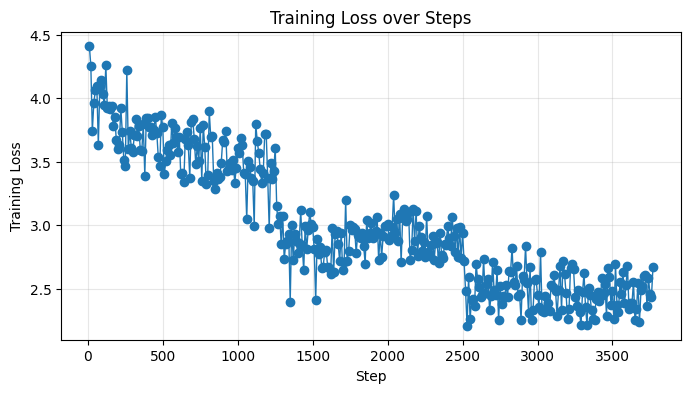

In [12]:
display(Markdown("# Training Loss Curve"))

if not train_logs.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", linewidth=1)
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.title("Training Loss over Steps")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No training logs found.")

# Validation ROUGE over Epochs

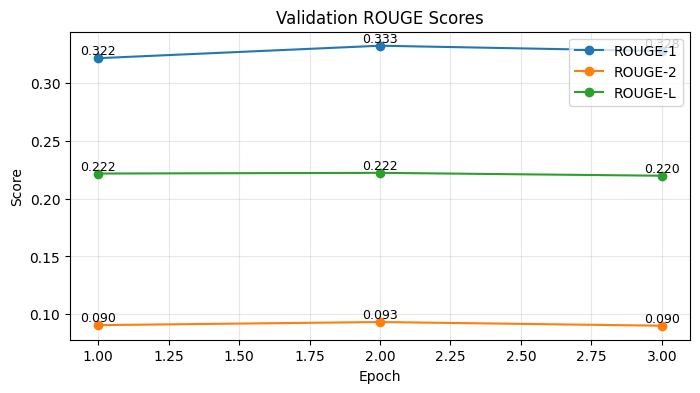

In [19]:
display(Markdown("# Validation ROUGE over Epochs"))

if not eval_logs.empty:
    plt.figure(figsize=(8, 4))

    if "eval_rouge1" in eval_logs.columns:
        plt.plot(eval_logs["epoch"], eval_logs["eval_rouge1"], marker="o", label="ROUGE-1")
        for x, y in zip(eval_logs["epoch"], eval_logs["eval_rouge1"]):
            plt.text(x, y + 0.003, f"{y:.3f}", ha="center", fontsize=9)

    if "eval_rouge2" in eval_logs.columns:
        plt.plot(eval_logs["epoch"], eval_logs["eval_rouge2"], marker="o", label="ROUGE-2")
        for x, y in zip(eval_logs["epoch"], eval_logs["eval_rouge2"]):
            plt.text(x, y + 0.003, f"{y:.3f}", ha="center", fontsize=9)

    if "eval_rougeL" in eval_logs.columns:
        plt.plot(eval_logs["epoch"], eval_logs["eval_rougeL"], marker="o", label="ROUGE-L")
        for x, y in zip(eval_logs["epoch"], eval_logs["eval_rougeL"]):
            plt.text(x, y + 0.003, f"{y:.3f}", ha="center", fontsize=9)

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Validation ROUGE Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

else:
    print("No evaluation logs found.")

# Final Validation ROUGE Scores

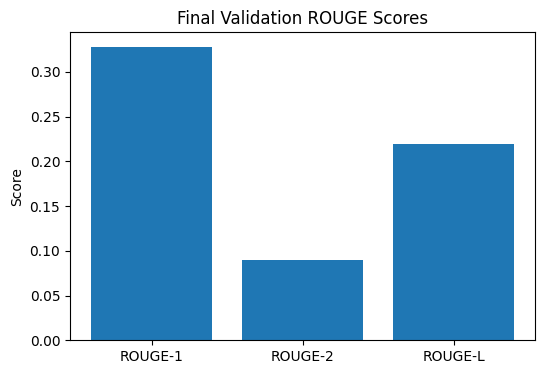

{'ROUGE-1': np.float64(0.3279), 'ROUGE-2': np.float64(0.09), 'ROUGE-L': np.float64(0.2199)}


In [14]:
display(Markdown("# Final Validation ROUGE Scores"))

if not eval_logs.empty:
    last_eval = eval_logs.iloc[-1]

    scores = {
        "ROUGE-1": last_eval.get("eval_rouge1"),
        "ROUGE-2": last_eval.get("eval_rouge2"),
        "ROUGE-L": last_eval.get("eval_rougeL"),
    }

    plt.figure(figsize=(6, 4))
    plt.bar(scores.keys(), scores.values())
    plt.ylabel("Score")
    plt.title("Final Validation ROUGE Scores")
    plt.show()

    print(scores)
else:
    print("No evaluation logs found.")

In [15]:
sample_rows = []
with open(SAMPLE_PREDS_FILE, "r", encoding="utf-8") as f:
    for line in f:
        sample_rows.append(json.loads(line))

samples_df = pd.DataFrame(sample_rows)

display(Markdown("# Sample Predictions"))
display(samples_df.head())

# Sample Predictions

,meeting_id,query,reference_summary,generated_summary
0,test_0,Summarize the whole meeting.,This meeting was the eleventh evidence session...,The meeting was mainly about the Abolition of ...
1,test_0,Summarize the discussion about the efficacy of...,Barry Hughes first stated that children had fe...,"According to Barry Hughes, the Bill was very c..."
2,test_0,What did Barry Hughes think about the legal fr...,Barry thought that the legal framework would m...,"When talking about the efficacy of the law, Ba..."
3,test_0,What was the two-stage test during prosecution...,The first stage was to check whether there was...,The two-stage test during prosecutions was whe...
4,test_0,Summarize the discussion about the divergence ...,Barry Hughes indicated that the Bill would imp...,According to the Deputy Crown Prosecution Serv...


In [16]:
for i, row in samples_df.iterrows():
    md = f"""
## Example {i+1}

**Meeting ID:** {row['meeting_id']}

**Query:**  
{row['query']}

**Reference Summary:**  
{row['reference_summary']}

**Generated Summary:**  
{row['generated_summary']}
"""
    display(Markdown(md))


## Example 1

**Meeting ID:** test_0

**Query:**  
Summarize the whole meeting.

**Reference Summary:**  
This meeting was the eleventh evidence session on the Children Abolition of Defense of Reasonable Publishment Wales Bill. Barry Hughes was there to answer questions related to the Bill. Six main topics that had been discussed or explained. The first one was how the Bill protected the children in terms of prosecutions. The

**Generated Summary:**  
The meeting was mainly about the Abolition of Defense of Reasonable Punishment in Wales. Firstly, the Chief Crown Prosecutor for Wales, Kwame Biney, and Iwan Jenkins, who is head of the complex casework unit, Cymru Wales, gave their views on the Bill. Then, the Deputy Prime Minister introduced the Bill



## Example 2

**Meeting ID:** test_0

**Query:**  
Summarize the discussion about the efficacy of the law.

**Reference Summary:**  
Barry Hughes first stated that children had fewer rights than adults and therefore the law should be enforced to defend physical assault. As such social behavior was not available now, the law should change to reflect that. The discussion then turned to talk about the legal framework and its prosecution.

**Generated Summary:**  
According to Barry Hughes, the Bill was very clear that it was an effective law in terms of protecting children and their families. Hefin David and Jack Sargeant thought it was very important to see the effectiveness of the law. However, Sian Gwenllian believed that the Bill did not have a



## Example 3

**Meeting ID:** test_0

**Query:**  
What did Barry Hughes think about the legal framework when talking about the efficacy of the law?

**Reference Summary:**  
Barry thought that the legal framework would make things clearer for parents and professionals. But when it came to prosecuting, there was a degree of confusion and some cases were in the grey areas.

**Generated Summary:**  
When talking about the efficacy of the law, Barry Hughes thought that it was a great legal framework. He thought that they had a strong legal system. Hefin David and Jack Sargeant were very supportive of the Bill. However, he thought that the Bill was not as effective as it was supposed to be



## Example 4

**Meeting ID:** test_0

**Query:**  
What was the two-stage test during prosecutions when discussing the efficacy of the law?

**Reference Summary:**  
The first stage was to check whether there was sufficient evidence submitted by the police to provide a realistic prospect of conviction. Only if the first stage was satisfied, the second stage came to be considered, which was in the public interest.

**Generated Summary:**  
The two-stage test during prosecutions was whether the law was effective or not. The first stage was whether it was effective. The second stage was when it was clear that it was not. Then the third stage was to see the effectiveness of the law. The third was when they were making sure that they were



## Example 5

**Meeting ID:** test_0

**Query:**  
Summarize the discussion about the divergence between the law in England and Wales.

**Reference Summary:**  
Barry Hughes indicated that the Bill would impact England and their people, although it needed a period. Moreover, Barry thought there was no cross-border issue from the potential legislation, and the draft changing to CPS guidance would not be helpful for scrutinisers to decide on the law in Wales.

**Generated Summary:**  
According to the Deputy Crown Prosecution Service, there was a huge difference between the two countries. In England, the law did not change much, and in Wales, it did change a bit. However, the difference between England and Wales was not clear. In Wales, the Bill did change the law, and



## Example 6

**Meeting ID:** test_0

**Query:**  
What did Barry Hughes think about the implications for implementing the Bill in Wales when talking about the divergence between the law in England and Wales?

**Reference Summary:**  
Barry Hughes concluded two kinds of implications. First, the Bill would raise awareness for people from England who travel to Wales. Second, people in other areas might reflect on this defense as they did to the drink driving limit in Scotland.

**Generated Summary:**  
Barry Hughes thought that the Bill was very clear about the implications for implementation of the Bill in England and Wales. He thought that they would have to work together to implement the Bill, but they would not necessarily have to do that in England or Wales. They would need to work with the Crown Prosecution Service Cymru Wales.



## Example 7

**Meeting ID:** test_0

**Query:**  
What did Barry Hughes think about draft changes to CPS guidance when talking about the divergence between the law in England and Wales?

**Reference Summary:**  
Barry Hughes thought draft changes to CPS guidance would not necessarily be helpful to the scrutinisers, and simply wanted to take the present interest factors. Barry thought they needed to work for the principles of generality and a degree of specificity.

**Generated Summary:**  
Barry Hughes thought that they were very pleased with the draft changes to the law in England and Wales. They were very clear about the difference between the UK and Wales, but they were not sure about the differences between the two countries. Hefin David and Jack Sargeant were very supportive of the draft change to CPS guidance.



## Example 8

**Meeting ID:** test_0

**Query:**  
Summarize the discussion about out-of-court disposals.

**Reference Summary:**  
Barry Hughes introduced their cooperated organizations the National Police Chiefs' Council and their work on the out-of-court disposals. Then, Hughes and Vikki Howells talked about the possibility of creating a body of out-of-court disposals specific to the Bill. Lastly, there was a short

**Generated Summary:**  
The group discussed the out-of-court disposals of children and young people in Wales. They discussed the impact on the Bill on the future of the Bill. The group also discussed how they would be able to continue to collect the money that they had collected from the Crown Prosecution Service Cymru Wales. In terms of the overall disposals



## Example 9

**Meeting ID:** test_0

**Query:**  
How did the National Police Chiefs' Council help in out-of-court disposals?

**Reference Summary:**  
The National Police Chiefs' Council was responsible for developing the police approach to out-of-court disposals and simplifying the range of out-of-court disposals.

**Generated Summary:**  
The National Police Chiefs' Council helped in out-of-court disposals. They were very pleased that they had been able to get the support they needed. They had been working with local authorities and local authorities to help with the out of court disposals of children and young people. And they were also working



## Example 10

**Meeting ID:** test_0

**Query:**  
What did Barry Hughes think about the infrastructure of out-of-court disposals?

**Reference Summary:**  
Barry Hughes thought that the infrastructure can be built for a range of out-of-court disposals. It might be built by the Welsh Government, the police, and crime commissioners.

**Generated Summary:**  
Barry Hughes thought that they had an infrastructure of out-of-court disposals. He thought that it was a good idea to have a system in which they would be able to use. He believed that it would be a great thing to see if they were to use it.


In [17]:
display(Markdown("# Results Table"))

if not eval_logs.empty:
    final_row = eval_logs.iloc[-1]

    results_table = pd.DataFrame([
        {
            "Model": "Fine-tuned BART",
            "ROUGE-1": final_row.get("eval_rouge1"),
            "ROUGE-2": final_row.get("eval_rouge2"),
            "ROUGE-L": final_row.get("eval_rougeL"),
            "Eval Loss": final_row.get("eval_loss"),
            "Avg Gen Length": final_row.get("eval_gen_len"),
        }
    ])

    display(results_table)
else:
    print("No evaluation logs found.")

# Results Table

,Model,ROUGE-1,ROUGE-2,ROUGE-L,Eval Loss,Avg Gen Length
0,Fine-tuned BART,0.3279,0.09,0.2199,3.555228,65.0147
